read files

In [135]:
from pathlib import Path
import pandas as pd

# Project paths
PROJECT_ROOT = Path(".").resolve()
RAW_DIR = PROJECT_ROOT / "raw-data"

print("Reading from:", RAW_DIR)


# Container for datasets
datasets = {}


# Read CSV
def read_csv_safe(path):
    for enc in ["utf-8", "utf-8-sig", "latin1"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    print(f"Failed CSV:", path)
    return None


# Read Excel

def read_excel_safe(path):
    try:
        if path.suffix.lower() == ".xls":
            return pd.read_excel(path, engine="xlrd")
        else:
            return pd.read_excel(path)
    except Exception as e:
        print(f"Failed Excel:", path, e)
        return None

# Scan all files

for file in RAW_DIR.rglob("*"):

    if file.is_dir():
        continue

    ext = file.suffix.lower()

    # skip metadata + documentation
    if "metadata" in file.name.lower():
        continue

    if ext == ".pdf":
        continue

    relative_name = str(file.relative_to(RAW_DIR))

    print("Loading:", relative_name)

    df = None

    if ext == ".csv":
        df = read_csv_safe(file)

    elif ext in [".xls", ".xlsx"]:
        df = read_excel_safe(file)

    if df is not None:
        datasets[relative_name] = df


print("\n Loaded datasets:", len(datasets))

Reading from: C:\Users\elain\OneDrive\Desktop\733-project\raw-data
Loading: canadian-agricultural-import-data\avocado\2016.csv
Loading: canadian-agricultural-import-data\avocado\2017.csv
Loading: canadian-agricultural-import-data\avocado\2018.csv
Loading: canadian-agricultural-import-data\avocado\2019.csv
Loading: canadian-agricultural-import-data\avocado\2020.csv
Loading: canadian-agricultural-import-data\avocado\2021.csv
Loading: canadian-agricultural-import-data\avocado\2022.csv
Loading: canadian-agricultural-import-data\avocado\2023.csv
Loading: canadian-agricultural-import-data\avocado\2024.csv
Loading: canadian-agricultural-import-data\avocado\2025.csv
Loading: canadian-agricultural-import-data\tomato\2016.csv
Loading: canadian-agricultural-import-data\tomato\2017.csv
Loading: canadian-agricultural-import-data\tomato\2018.csv
Loading: canadian-agricultural-import-data\tomato\2019.csv
Loading: canadian-agricultural-import-data\tomato\2020.csv
Loading: canadian-agricultural-import-

C:\Users\elain\AppData\Local\Temp\ipykernel_13644\778118582.py:19: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, encoding=enc)


In [144]:
datasets.keys()

dict_keys(['canadian-agricultural-import-data\\avocado\\2016.csv', 'canadian-agricultural-import-data\\avocado\\2017.csv', 'canadian-agricultural-import-data\\avocado\\2018.csv', 'canadian-agricultural-import-data\\avocado\\2019.csv', 'canadian-agricultural-import-data\\avocado\\2020.csv', 'canadian-agricultural-import-data\\avocado\\2021.csv', 'canadian-agricultural-import-data\\avocado\\2022.csv', 'canadian-agricultural-import-data\\avocado\\2023.csv', 'canadian-agricultural-import-data\\avocado\\2024.csv', 'canadian-agricultural-import-data\\avocado\\2025.csv', 'canadian-agricultural-import-data\\tomato\\2016.csv', 'canadian-agricultural-import-data\\tomato\\2017.csv', 'canadian-agricultural-import-data\\tomato\\2018.csv', 'canadian-agricultural-import-data\\tomato\\2019.csv', 'canadian-agricultural-import-data\\tomato\\2020.csv', 'canadian-agricultural-import-data\\tomato\\2021.csv', 'canadian-agricultural-import-data\\tomato\\2022.csv', 'canadian-agricultural-import-data\\tomato\\

first check

Target Variable: Canadian Grocery Prices

In [152]:
import pandas as pd

# 1) Load grocery prices dataset
price = datasets['canadian-grocery-prices\\18100245.csv']

print("Full grocery price dataset shape:", price.shape)


# 2) Filter FRESH tomato only
#    (exclude canned tomatoes)
tomato_price = price[
    (price["Products"].str.contains("Tomato", case=False, na=False)) &
    (~price["Products"].str.contains("Canned", case=False, na=False))
].copy()

# Keep Canada only
tomato_price = tomato_price[
    tomato_price["GEO"] == "Canada"
].copy()

print("\nFresh Tomato dataset shape (Canada only):", tomato_price.shape)
print("Fresh Tomato sample rows:")
display(tomato_price.head())


# 3) Filter avocado only
avocado_price = price[
    price["Products"].str.contains("Avocado", case=False, na=False)
].copy()

# Keep Canada only
avocado_price = avocado_price[
    avocado_price["GEO"] == "Canada"
].copy()

print("\nAvocado dataset shape (Canada only):", avocado_price.shape)
print("Avocado sample rows:")
display(avocado_price.head())


# 4) Convert REF_DATE → datetime

tomato_price["date"] = pd.to_datetime(
    tomato_price["REF_DATE"],
    errors="coerce"
)

avocado_price["date"] = pd.to_datetime(
    avocado_price["REF_DATE"],
    errors="coerce"
)


# 5) Check time range

print("\nFresh Tomato time range:")
print(
    tomato_price["date"].min(),
    "→",
    tomato_price["date"].max()
)

print("\nAvocado time range:")
print(
    avocado_price["date"].min(),
    "→",
    avocado_price["date"].max()
)

Full grocery price dataset shape: (130968, 15)

Fresh Tomato dataset shape (Canada only): (108, 15)
Fresh Tomato sample rows:


,REF_DATE,GEO,DGUID,Products,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
44,2017-01,Canada,2021A000011124,"Tomatoes, per kilogram",Dollars,81,units,0,v1353834301,11.31,4.48,NaN,NaN,NaN,2
1253,2017-02,Canada,2021A000011124,"Tomatoes, per kilogram",Dollars,81,units,0,v1353834301,11.31,4.19,NaN,NaN,NaN,2
2462,2017-03,Canada,2021A000011124,"Tomatoes, per kilogram",Dollars,81,units,0,v1353834301,11.31,3.83,NaN,NaN,NaN,2
3671,2017-04,Canada,2021A000011124,"Tomatoes, per kilogram",Dollars,81,units,0,v1353834301,11.31,3.34,NaN,NaN,NaN,2
4880,2017-05,Canada,2021A000011124,"Tomatoes, per kilogram",Dollars,81,units,0,v1353834301,11.31,3.13,NaN,NaN,NaN,2



Avocado dataset shape (Canada only): (108, 15)
Avocado sample rows:


,REF_DATE,GEO,DGUID,Products,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
40,2017-01,Canada,2021A000011124,"Avocado, unit",Dollars,81,units,0,v1353834299,11.29,1.51,NaN,NaN,NaN,2
1249,2017-02,Canada,2021A000011124,"Avocado, unit",Dollars,81,units,0,v1353834299,11.29,1.52,NaN,NaN,NaN,2
2458,2017-03,Canada,2021A000011124,"Avocado, unit",Dollars,81,units,0,v1353834299,11.29,1.66,NaN,NaN,NaN,2
3667,2017-04,Canada,2021A000011124,"Avocado, unit",Dollars,81,units,0,v1353834299,11.29,1.92,NaN,NaN,NaN,2
4876,2017-05,Canada,2021A000011124,"Avocado, unit",Dollars,81,units,0,v1353834299,11.29,2.14,NaN,NaN,NaN,2



Fresh Tomato time range:
2017-01-01 00:00:00 → 2025-12-01 00:00:00

Avocado time range:
2017-01-01 00:00:00 → 2025-12-01 00:00:00


plot tomato and avocade price
"Tomatoes, per kilogram"
Avocado unit ???

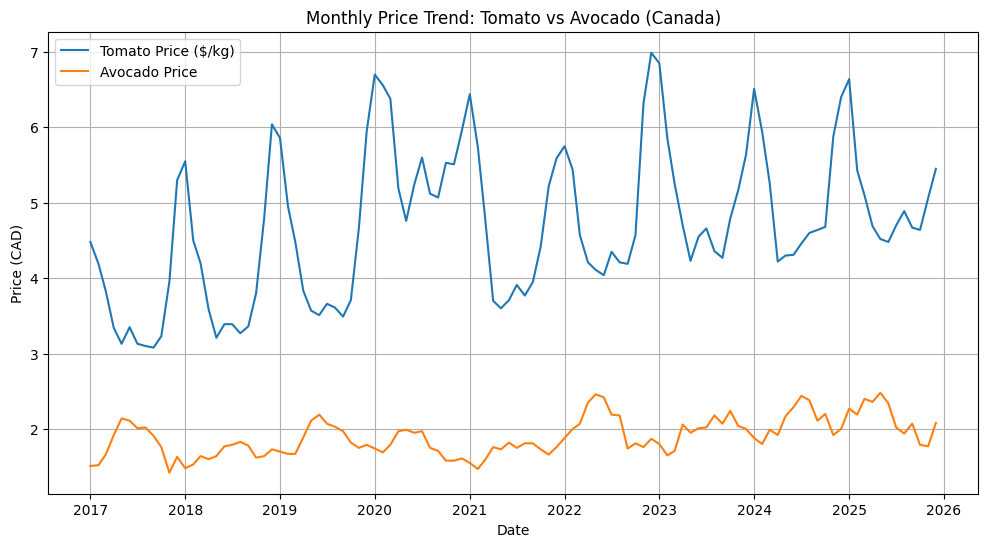

In [159]:
import matplotlib.pyplot as plt


# 1) Prepare tomato time series

tomato_ts = (
    tomato_price
    .sort_values("date")
    .set_index("date")["VALUE"]
)


# 2) Prepare avocado time series

avocado_ts = (
    avocado_price
    .sort_values("date")
    .set_index("date")["VALUE"]
)


plt.figure(figsize=(12,6))

plt.plot(tomato_ts.index, tomato_ts.values, label="Tomato Price ($/kg)")
plt.plot(avocado_ts.index, avocado_ts.values, label="Avocado Price")

plt.title("Monthly Price Trend: Tomato vs Avocado (Canada)")
plt.xlabel("Date")
plt.ylabel("Price (CAD)")
plt.legend()

plt.grid(True)

plt.show()

inflation check

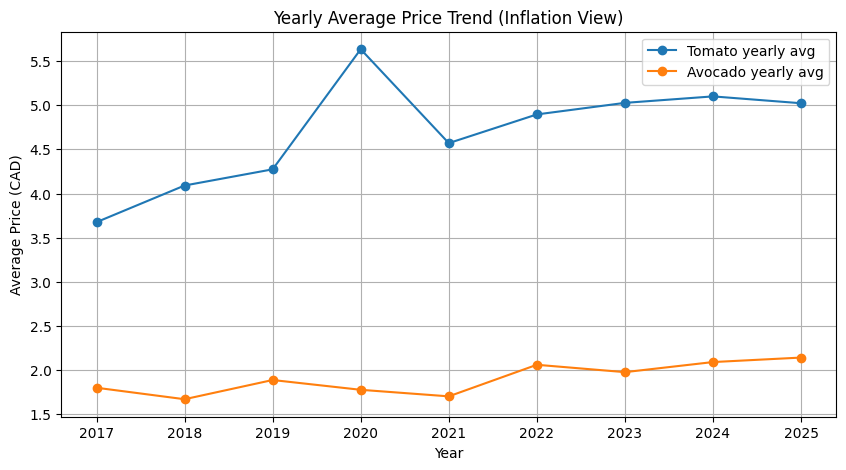

In [165]:
tomato_yearly = tomato_price.groupby(
    tomato_price["date"].dt.year
)["VALUE"].mean()

avocado_yearly = avocado_price.groupby(
    avocado_price["date"].dt.year
)["VALUE"].mean()

plt.figure(figsize=(10,5))

plt.plot(tomato_yearly, marker="o", label="Tomato yearly avg")
plt.plot(avocado_yearly, marker="o", label="Avocado yearly avg")

plt.title("Yearly Average Price Trend (Inflation View)")
plt.xlabel("Year")
plt.ylabel("Average Price (CAD)")

plt.legend()
plt.grid(True)

plt.show()

try decompose inflation with seasonality

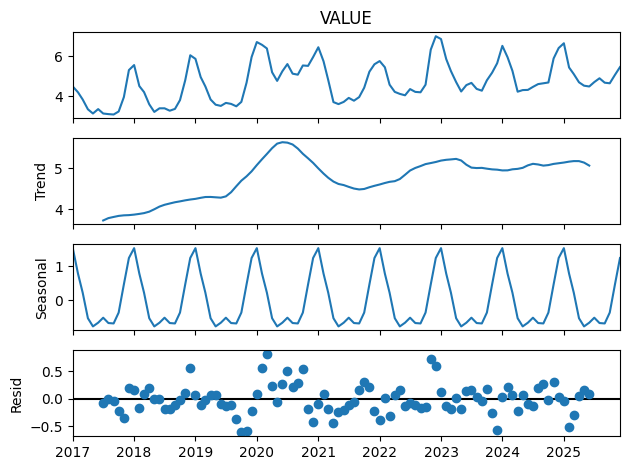

In [170]:

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    tomato_ts,
    model="additive",
    period=12
)

result.plot()
plt.show()

Weather data 
some useful column:
| Column | Meaning             |
| ------ | ------------------- |
| DATE   | month               |
| TAVG   | average temperature |
| TMAX   | max temperature     |
| TMIN   | min temperature     |
| PRCP   | precipitation       |


In [174]:
import pandas as pd
import matplotlib.pyplot as plt


# Step 1 — Load weather dataset

weather = datasets['country-weather\\mexico_weather.csv']

print("Original dataset shape:", weather.shape)



# # Step 2 — Keep useful columns only
# # (Temperature + Rainfall indicators)
# weather = weather[
#     [
#         "STATION",
#         "NAME",
#         "DATE",
#         "TAVG",
#         "TMAX",
#         "TMIN",
#         "PRCP"
#     ]
# ].copy()

# print("\nAfter column selection:")
# display(weather.head())

##### missing value
missing_pct = weather.isna().mean() * 100
with pd.option_context("display.max_rows", None):
    display(missing_pct.sort_values(ascending=False))


# Convert date
weather["date"] = pd.to_datetime(weather["DATE"], errors="coerce")

# Convert numeric columns
numeric_cols = ["TAVG", "TMAX", "TMIN", "PRCP"]

for col in numeric_cols:
    weather[col] = pd.to_numeric(weather[col], errors="coerce")

#print("\nData types after cleaning:")
#print(weather.dtypes)




Original dataset shape: (4910, 69)


DYFG_ATTRIBUTES    100.000000
DYTS_ATTRIBUTES    100.000000
DYFG                99.837067
DYTS                99.755601
DYSN                97.270876
EMSN                97.270876
SNOW_ATTRIBUTES     97.270876
SNOW                97.270876
EMSN_ATTRIBUTES     97.270876
DSNW                97.270876
DYSN_ATTRIBUTES     97.270876
DSNW_ATTRIBUTES     97.270876
DYSD_ATTRIBUTES     96.904277
EMSD_ATTRIBUTES     96.904277
EMSD                96.904277
DSND_ATTRIBUTES     96.904277
DSND                96.904277
DYSD                96.904277
CDSD_ATTRIBUTES     89.083503
HDSD_ATTRIBUTES     88.920570
CDSD                87.657841
HDSD                87.107943
TMAX_ATTRIBUTES     67.311609
TAVG_ATTRIBUTES     67.311609
TMAX                67.311609
HTDD                67.311609
TMIN                67.311609
DX32                67.311609
DX32_ATTRIBUTES     67.311609
DX90                67.311609
DX70_ATTRIBUTES     67.311609
DX70                67.311609
DT00_ATTRIBUTES     67.311609
DT00      

Canada gas price

In [177]:
import pandas as pd
import matplotlib.pyplot as plt


# 1) Load dataset
gas_raw = datasets['gas-price\\canada\\18100001.csv']



# 2) Keep useful columns only
gas = gas_raw[
    [
        "REF_DATE",
        "GEO",
        "Type of fuel",
        "VALUE"
    ]
].copy()

# Convert date
gas["date"] = pd.to_datetime(gas["REF_DATE"], errors="coerce")



# 3) Filter time range FIRST
start_date = "2017-01-01"
end_date = "2025-12-01"

gas = gas[
    (gas["date"] >= start_date) &
    (gas["date"] <= end_date)
].copy()

print("\nAfter time filtering:", gas.shape)



# 4) Keep SELF-SERVICE Regular Gasoline
gas_regular_self = gas[
    gas["Type of fuel"].str.contains(
        "Regular unleaded gasoline at self service",
        case=False,
        na=False
    )
].copy()

print("\nRegular gasoline shape:",
      gas_regular_self.shape)

display(gas_regular_self.head())


# 5) Keep SELF-SERVICE Diesel

gas_diesel_self = gas[
    gas["Type of fuel"].str.contains(
        "Diesel fuel at self service",
        case=False,
        na=False
    )
].copy()

print("\nDiesel shape:",
      gas_diesel_self.shape)

display(gas_diesel_self.head())


# 6) Examine available cities
print("\nAvailable GEO locations:")
display(sorted(gas_regular_self["GEO"].unique()))


# # 7) Coverage check
# print("\nRegular gasoline coverage:")
# display(
#     gas_regular_self
#     .groupby("GEO")["date"]
#     .count()
#     .sort_values(ascending=False)
# )

# print("\nDiesel coverage:")
# display(
#     gas_diesel_self
#     .groupby("GEO")["date"]
#     .count()
#     .sort_values(ascending=False)
# )


# 8) Create CITY Monthly Time Series
regular_city_ts = gas_regular_self.pivot_table(
    index="date",
    columns="GEO",
    values="VALUE"
).sort_index()

diesel_city_ts = gas_diesel_self.pivot_table(
    index="date",
    columns="GEO",
    values="VALUE"
).sort_index()

print("\nRegular TS shape:", regular_city_ts.shape)
print("Diesel TS shape:", diesel_city_ts.shape)

display(regular_city_ts.head())
display(diesel_city_ts.head())


# 9) Missing value check

print("\nMissing % Regular gasoline:")
display(
    (regular_city_ts.isna().mean()*100)
    .sort_values(ascending=False)
)

print("\nMissing % Diesel:")
display(
    (diesel_city_ts.isna().mean()*100)
    .sort_values(ascending=False)
)





After time filtering: (7560, 5)

Regular gasoline shape: (2052, 5)


,REF_DATE,GEO,Type of fuel,VALUE,date
38072,2017-01,Canada,Regular unleaded gasoline at self service fill...,112.2,2017-01-01
38073,2017-01,"St. John's, Newfoundland and Labrador",Regular unleaded gasoline at self service fill...,137.5,2017-01-01
38077,2017-01,"Charlottetown and Summerside, Prince Edward Is...",Regular unleaded gasoline at self service fill...,112.9,2017-01-01
38081,2017-01,"Halifax, Nova Scotia",Regular unleaded gasoline at self service fill...,111.8,2017-01-01
38085,2017-01,"Saint John, New Brunswick",Regular unleaded gasoline at self service fill...,111.3,2017-01-01



Diesel shape: (1836, 5)


,REF_DATE,GEO,Type of fuel,VALUE,date
38075,2017-01,"St. John's, Newfoundland and Labrador",Diesel fuel at self service filling stations,126.5,2017-01-01
38079,2017-01,"Charlottetown and Summerside, Prince Edward Is...",Diesel fuel at self service filling stations,117.6,2017-01-01
38083,2017-01,"Halifax, Nova Scotia",Diesel fuel at self service filling stations,109.8,2017-01-01
38087,2017-01,"Saint John, New Brunswick",Diesel fuel at self service filling stations,118.3,2017-01-01
38091,2017-01,"Québec, Quebec",Diesel fuel at self service filling stations,117.1,2017-01-01



Available GEO locations:


...

GEO,"Calgary, Alberta","Charlottetown and Summerside, Prince Edward Island","Edmonton, Alberta","Halifax, Nova Scotia","Montréal, Quebec","Ottawa-Gatineau, Ontario part, Ontario/Quebec","Québec, Quebec","Regina, Saskatchewan","Saint John, New Brunswick","Saskatoon, Saskatchewan","St. John's, Newfoundland and Labrador","Toronto, Ontario","Vancouver, British Columbia","Victoria, British Columbia","Whitehorse, Yukon","Winnipeg, Manitoba","Yellowknife, Northwest Territories"
date,,,,,,,,,,,,,,,,,
2017-01-01,104.6,117.6,103.5,109.8,116.1,108.5,117.1,97.9,118.3,98.8,126.5,108.6,118.9,113.9,113.2,102.9,117.9
2017-02-01,104.4,115.0,103.1,107.7,113.1,107.6,115.6,99.3,116.1,97.7,125.7,110.3,116.7,110.4,114.2,102.2,117.6
2017-03-01,104.9,113.4,103.8,104.3,112.7,105.3,113.2,100.2,112.3,98.1,122.9,107.0,116.7,110.7,112.4,101.9,118.6
2017-04-01,104.7,114.1,103.4,103.9,114.1,105.8,112.1,100.1,110.1,98.3,120.5,106.9,117.7,113.9,114.2,102.7,118.6
2017-05-01,102.5,110.4,101.7,98.0,109.5,103.9,111.0,98.6,105.4,97.8,112.4,104.9,118.7,112.6,114.4,101.4,114.6



Missing % Regular gasoline:


GEO
Calgary, Alberta                                      0.0
Canada                                                0.0
Charlottetown and Summerside, Prince Edward Island    0.0
Edmonton, Alberta                                     0.0
Halifax, Nova Scotia                                  0.0
Montréal, Quebec                                      0.0
Ottawa-Gatineau, Ontario part, Ontario/Quebec         0.0
Québec, Quebec                                        0.0
Regina, Saskatchewan                                  0.0
Saint John, New Brunswick                             0.0
Saskatoon, Saskatchewan                               0.0
St. John's, Newfoundland and Labrador                 0.0
Thunder Bay, Ontario                                  0.0
Toronto, Ontario                                      0.0
Vancouver, British Columbia                           0.0
Victoria, British Columbia                            0.0
Whitehorse, Yukon                                     0.0
Winnipeg, 


Missing % Diesel:


GEO
Calgary, Alberta                                      0.0
Charlottetown and Summerside, Prince Edward Island    0.0
Edmonton, Alberta                                     0.0
Halifax, Nova Scotia                                  0.0
Montréal, Quebec                                      0.0
Ottawa-Gatineau, Ontario part, Ontario/Quebec         0.0
Québec, Quebec                                        0.0
Regina, Saskatchewan                                  0.0
Saint John, New Brunswick                             0.0
Saskatoon, Saskatchewan                               0.0
St. John's, Newfoundland and Labrador                 0.0
Toronto, Ontario                                      0.0
Vancouver, British Columbia                           0.0
Victoria, British Columbia                            0.0
Whitehorse, Yukon                                     0.0
Winnipeg, Manitoba                                    0.0
Yellowknife, Northwest Territories                    0.0
dtype: flo

<Figure size 1200x500 with 0 Axes>

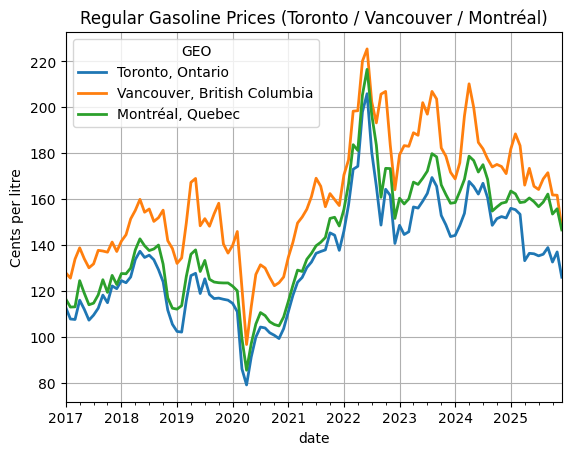

<Figure size 1200x500 with 0 Axes>

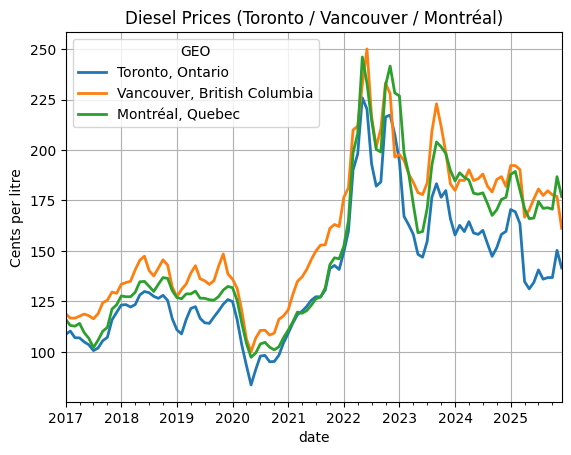

In [179]:

# 10) Visualization — toronto vancouverr montreal only

top_cities = [
    "Toronto, Ontario",
    "Vancouver, British Columbia",
    "Montréal, Quebec"
]

# ---- Regular Gasoline ----
plt.figure(figsize=(12,5))

regular_city_ts[top_cities].plot(
    linewidth=2
)

plt.title("Regular Gasoline Prices (Toronto / Vancouver / Montréal)")
plt.ylabel("Cents per litre")

plt.grid(True)
plt.show()


# ---- Diesel ----
plt.figure(figsize=(12,5))

diesel_city_ts[top_cities].plot(
    linewidth=2
)

plt.title("Diesel Prices (Toronto / Vancouver / Montréal)")
plt.ylabel("Cents per litre")

plt.grid(True)
plt.show()

US gas price:
This dataset is U.S. national-level gasoline prices (nationwide average), not city or state/province level.

weird structure .... need more time cleaning it